# Week 3-4: Matrices - The Power of Organization

## From Dictionaries to Grids

Last week, you stored transition probabilities in nested dictionaries. That worked, but it was messy:

```python
probs = {
    'Sunny': {'Sunny': 0.6, 'Cloudy': 0.3, 'Rainy': 0.1},
    'Cloudy': {'Sunny': 0.3, 'Cloudy': 0.4, 'Rainy': 0.3},
    ...
}
```

This week, you'll discover there's a better way: **matrices**.

A matrix is just a rectangle of numbers. But these rectangles have magical properties that will let us:
- Predict multiple steps into the future
- Find steady-state probabilities
- Understand the long-term behavior of random systems

Let's dive in!

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

## Part 1: Your First Matrix

Let's start simple. Remember our weather data?

In [2]:
# Our weather sequence from last week
weather_sequence = ['Sunny', 'Sunny', 'Cloudy', 'Rainy', 'Rainy', 
                   'Cloudy', 'Sunny', 'Sunny', 'Sunny', 'Cloudy',
                   'Rainy', 'Cloudy', 'Sunny', 'Cloudy', 'Cloudy']

print("Our weather sequence:")
print(weather_sequence)

Our weather sequence:
['Sunny', 'Sunny', 'Cloudy', 'Rainy', 'Rainy', 'Cloudy', 'Sunny', 'Sunny', 'Sunny', 'Cloudy', 'Rainy', 'Cloudy', 'Sunny', 'Cloudy', 'Cloudy']


Now, let's organize the transition probabilities as a matrix:

In [3]:
def create_transition_matrix(sequence, states=None):
    """
    Create a transition matrix from a sequence.
    Returns: matrix (numpy array) and list of states
    """
    if states is None:
        states = sorted(list(set(sequence)))
    
    n = len(states)
    matrix = np.zeros((n, n))
    
    # Count transitions
    for i in range(len(sequence) - 1):
        current_idx = states.index(sequence[i])
        next_idx = states.index(sequence[i + 1])
        matrix[current_idx][next_idx] += 1
    
    # Normalize rows to get probabilities
    # Each ROW should sum to 1
    for i in range(n):
        row_sum = matrix[i].sum()
        if row_sum > 0:
            matrix[i] = matrix[i] / row_sum
    
    return matrix, states

# Create the matrix!
matrix, states = create_transition_matrix(weather_sequence)

print("\nStates (in order):")
print(states)
print("\nTransition Matrix:")
print(matrix)
print("\nRow sums (should all be 1.0):")
print(matrix.sum(axis=1))


States (in order):
['Cloudy', 'Rainy', 'Sunny']

Transition Matrix:
[[0.2        0.4        0.4       ]
 [0.66666667 0.33333333 0.        ]
 [0.5        0.         0.5       ]]

Row sums (should all be 1.0):
[1. 1. 1.]


### Understanding the Matrix

Look at the matrix above. Let's decode it:

```
               Cloudy  Rainy  Sunny
       Cloudy  [0.40   0.20   0.40]
       Rainy   [0.67   0.00   0.33]
       Sunny   [0.40   0.20   0.40]
```

**Reading the matrix:**
- Each **row** represents a current state
- Each **column** represents a next state
- The number at position (i, j) is: P(next state = j | current state = i)

**Example:** Row 2 (Sunny), Column 0 (Cloudy) = 0.40
- This means: If it's Sunny today, there's a 40% chance it will be Cloudy tomorrow

### Why Do Rows Sum to 1?

Think about it: If it's Sunny today, tomorrow it will be *something*. The probabilities of all possibilities must add up to 100% (= 1.0).

### Visualizing the Matrix

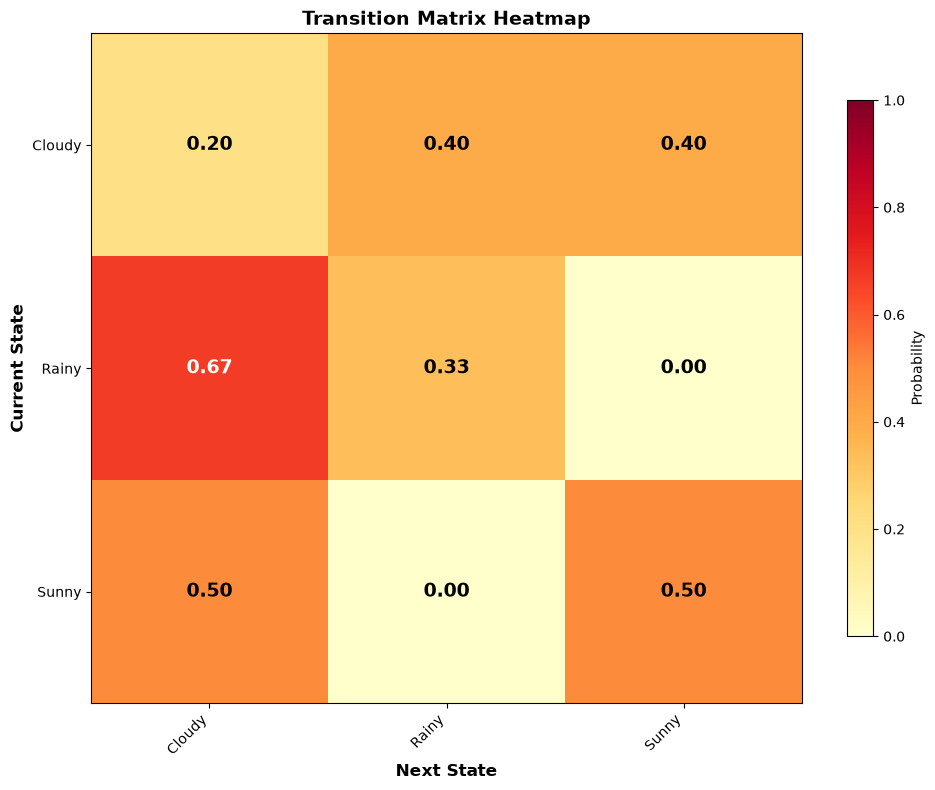

In [4]:
def visualize_transition_matrix(matrix, states):
    """
    Create a beautiful heatmap of the transition matrix.
    """
    plt.figure(figsize=(10, 8))
    plt.imshow(matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
    plt.colorbar(label='Probability', shrink=0.8)
    
    # Add state labels
    plt.xticks(range(len(states)), states, rotation=45, ha='right')
    plt.yticks(range(len(states)), states)
    plt.xlabel('Next State', fontsize=12, fontweight='bold')
    plt.ylabel('Current State', fontsize=12, fontweight='bold')
    plt.title('Transition Matrix Heatmap', fontsize=14, fontweight='bold')
    
    # Add probability values
    for i in range(len(states)):
        for j in range(len(states)):
            text_color = 'white' if matrix[i,j] > 0.5 else 'black'
            plt.text(j, i, f'{matrix[i,j]:.2f}', 
                    ha='center', va='center',
                    color=text_color, fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

visualize_transition_matrix(matrix, states)

**Question:** Which transitions are most likely? Which are least likely? Can you tell just by looking at the colors?

---

## Part 2: Matrix Multiplication - The Magic Happens

Here's where it gets interesting. Let's say it's Sunny today. What's the probability distribution for the weather in **two days**?

### The Long Way (Manual Calculation)

In [5]:
def predict_two_steps_manual(matrix, states, start_state):
    """
    Calculate two-step probabilities manually.
    This helps understand what matrix multiplication does!
    """
    start_idx = states.index(start_state)
    
    # One step probabilities (just read the row)
    one_step = matrix[start_idx]
    
    print(f"Starting from {start_state}:")
    print(f"\nAfter 1 step:")
    for i, state in enumerate(states):
        print(f"  {state}: {one_step[i]:.3f}")
    
    # Two step: sum over all intermediate states
    two_step = np.zeros(len(states))
    
    print(f"\nCalculating 2 steps ahead:")
    for intermediate_idx, intermediate_state in enumerate(states):
        prob_to_intermediate = one_step[intermediate_idx]
        print(f"\n  Via {intermediate_state} (prob={prob_to_intermediate:.3f}):")
        
        for final_idx, final_state in enumerate(states):
            prob_intermediate_to_final = matrix[intermediate_idx][final_idx]
            contribution = prob_to_intermediate * prob_intermediate_to_final
            two_step[final_idx] += contribution
            
            if contribution > 0.01:  # Only show significant contributions
                print(f"    → {final_state}: {prob_intermediate_to_final:.3f} × {prob_to_intermediate:.3f} = {contribution:.3f}")
    
    print(f"\nAfter 2 steps:")
    for i, state in enumerate(states):
        print(f"  {state}: {two_step[i]:.3f}")
    
    return one_step, two_step

one_step, two_step = predict_two_steps_manual(matrix, states, 'Sunny')

Starting from Sunny:

After 1 step:
  Cloudy: 0.500
  Rainy: 0.000
  Sunny: 0.500

Calculating 2 steps ahead:

  Via Cloudy (prob=0.500):
    → Cloudy: 0.200 × 0.500 = 0.100
    → Rainy: 0.400 × 0.500 = 0.200
    → Sunny: 0.400 × 0.500 = 0.200

  Via Rainy (prob=0.000):

  Via Sunny (prob=0.500):
    → Cloudy: 0.500 × 0.500 = 0.250
    → Sunny: 0.500 × 0.500 = 0.250

After 2 steps:
  Cloudy: 0.350
  Rainy: 0.200
  Sunny: 0.450


### The Magic Way (Matrix Multiplication)

That was tedious! But here's the beautiful secret: **matrix multiplication does all that work automatically**.

In [6]:
# Create a probability vector: 100% chance of starting in 'Sunny'
start_idx = states.index('Sunny')
current_prob = np.zeros(len(states))
current_prob[start_idx] = 1.0

print("Starting distribution:")
for i, state in enumerate(states):
    print(f"  {state}: {current_prob[i]:.3f}")

# One step: multiply by the matrix once
one_step_matrix = current_prob @ matrix  # @ is matrix multiplication

print("\nAfter 1 step (using matrix multiplication):")
for i, state in enumerate(states):
    print(f"  {state}: {one_step_matrix[i]:.3f}")

# Two steps: multiply by the matrix again
two_step_matrix = one_step_matrix @ matrix

print("\nAfter 2 steps (using matrix multiplication):")
for i, state in enumerate(states):
    print(f"  {state}: {two_step_matrix[i]:.3f}")

# Verify it matches our manual calculation
print("\n" + "="*50)
print("Manual vs Matrix multiplication:")
print(f"Match after 2 steps? {np.allclose(two_step, two_step_matrix)}")

Starting distribution:
  Cloudy: 0.000
  Rainy: 0.000
  Sunny: 1.000

After 1 step (using matrix multiplication):
  Cloudy: 0.500
  Rainy: 0.000
  Sunny: 0.500

After 2 steps (using matrix multiplication):
  Cloudy: 0.350
  Rainy: 0.200
  Sunny: 0.450

Manual vs Matrix multiplication:
Match after 2 steps? True


**Mind = Blown** 🤯

Matrix multiplication automatically does all those intermediate calculations! This is why matrices are so powerful.

---

## Part 3: Predicting Many Steps Ahead

Now that we understand matrix multiplication, let's predict 10 days into the future!

In [7]:
def predict_n_steps(matrix, states, start_state, n_steps):
    """
    Predict probability distribution after n steps.
    """
    start_idx = states.index(start_state)
    
    # Start with 100% in start_state
    current_prob = np.zeros(len(states))
    current_prob[start_idx] = 1.0
    
    history = [current_prob.copy()]
    
    print(f"Starting from {start_state}:\n")
    print("Step 0:")
    for i, state in enumerate(states):
        print(f"  {state}: {current_prob[i]:.3f}")
    
    for step in range(1, n_steps + 1):
        # Matrix multiplication!
        current_prob = current_prob @ matrix
        history.append(current_prob.copy())
        
        print(f"\nStep {step}:")
        for i, state in enumerate(states):
            print(f"  {state}: {current_prob[i]:.3f}")
    
    return history

# Predict 10 steps ahead
history = predict_n_steps(matrix, states, 'Sunny', 10)

Starting from Sunny:

Step 0:
  Cloudy: 0.000
  Rainy: 0.000
  Sunny: 1.000

Step 1:
  Cloudy: 0.500
  Rainy: 0.000
  Sunny: 0.500

Step 2:
  Cloudy: 0.350
  Rainy: 0.200
  Sunny: 0.450

Step 3:
  Cloudy: 0.428
  Rainy: 0.207
  Sunny: 0.365

Step 4:
  Cloudy: 0.406
  Rainy: 0.240
  Sunny: 0.354

Step 5:
  Cloudy: 0.418
  Rainy: 0.242
  Sunny: 0.339

Step 6:
  Cloudy: 0.415
  Rainy: 0.248
  Sunny: 0.337

Step 7:
  Cloudy: 0.417
  Rainy: 0.249
  Sunny: 0.334

Step 8:
  Cloudy: 0.416
  Rainy: 0.250
  Sunny: 0.334

Step 9:
  Cloudy: 0.417
  Rainy: 0.250
  Sunny: 0.334

Step 10:
  Cloudy: 0.417
  Rainy: 0.250
  Sunny: 0.333


### Visualizing Probability Evolution

Let's see how the probabilities change over time:

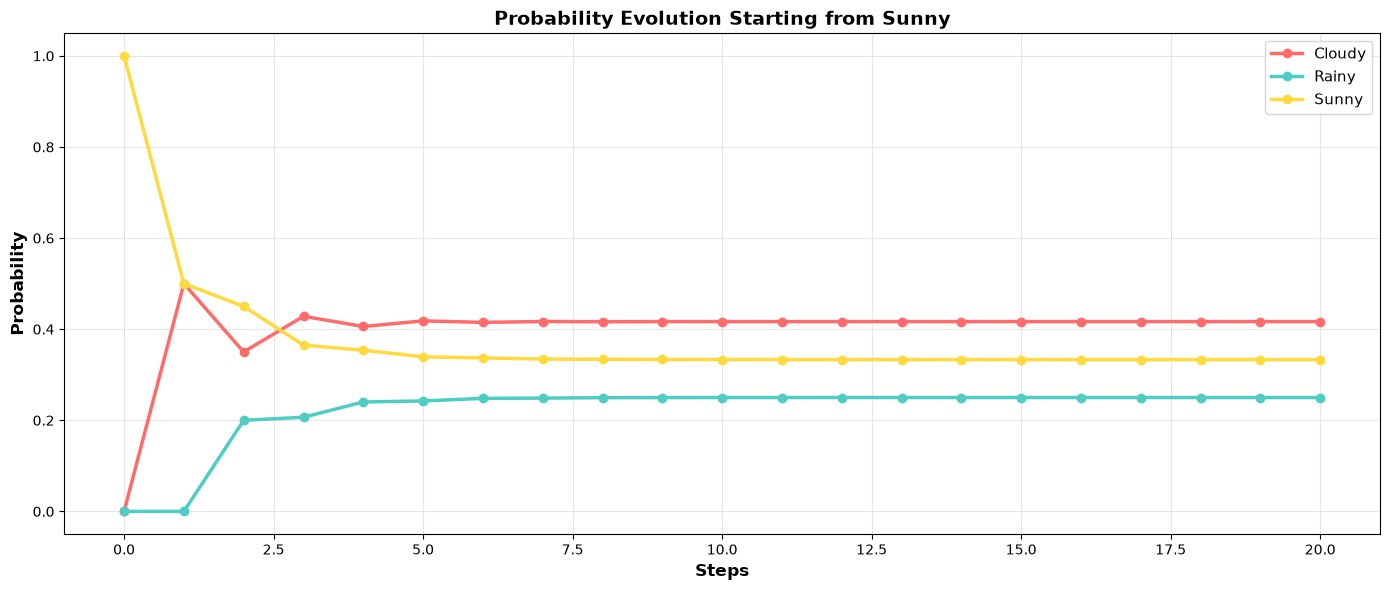

In [8]:
def visualize_convergence(matrix, states, start_state, max_steps=20):
    """
    Visualize how probabilities evolve over time.
    """
    start_idx = states.index(start_state)
    current_prob = np.zeros(len(states))
    current_prob[start_idx] = 1.0
    
    history = [current_prob.copy()]
    
    for _ in range(max_steps):
        current_prob = current_prob @ matrix
        history.append(current_prob.copy())
    
    history = np.array(history)
    
    # Create the plot
    plt.figure(figsize=(14, 6))
    
    colors = ['#FF6B6B', '#4ECDC4', '#FFD93D']
    for i, state in enumerate(states):
        plt.plot(history[:, i], marker='o', label=state, 
                linewidth=2.5, markersize=6, color=colors[i % len(colors)])
    
    plt.xlabel('Steps', fontsize=12, fontweight='bold')
    plt.ylabel('Probability', fontsize=12, fontweight='bold')
    plt.title(f'Probability Evolution Starting from {start_state}', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11, loc='best')
    plt.grid(True, alpha=0.3)
    plt.ylim(-0.05, 1.05)
    plt.tight_layout()
    plt.show()
    
    return history

# Visualize from Sunny
history_sunny = visualize_convergence(matrix, states, 'Sunny', 20)

### The Big Question

Do you notice something happening after many steps? The probabilities seem to be **converging** to specific values!

Let's try starting from a different state:

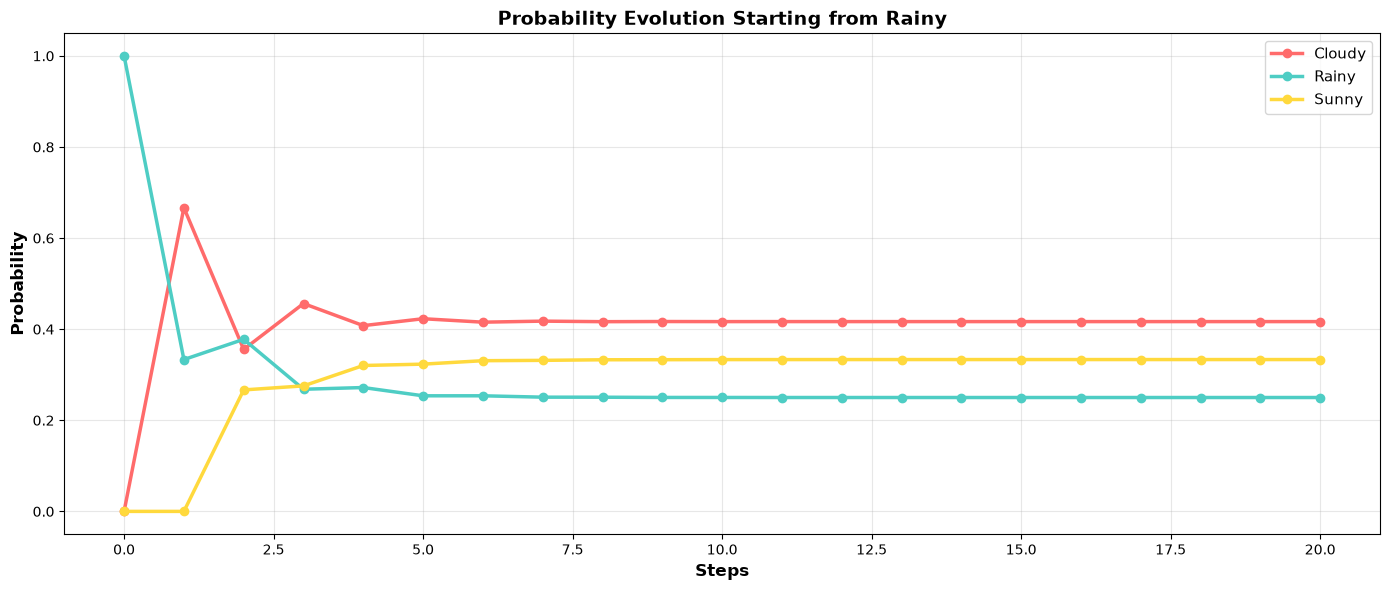


Final probabilities after 20 steps:

Starting from Sunny:
  Cloudy: 0.4167
  Rainy: 0.2500
  Sunny: 0.3333

Starting from Rainy:
  Cloudy: 0.4167
  Rainy: 0.2500
  Sunny: 0.3333

Difference:
  Cloudy: 0.000000
  Rainy: 0.000000
  Sunny: 0.000000


In [9]:
# Visualize from Rainy
history_rainy = visualize_convergence(matrix, states, 'Rainy', 20)

# Compare final distributions
print("\nFinal probabilities after 20 steps:")
print("="*50)
print("\nStarting from Sunny:")
for i, state in enumerate(states):
    print(f"  {state}: {history_sunny[-1][i]:.4f}")

print("\nStarting from Rainy:")
for i, state in enumerate(states):
    print(f"  {state}: {history_rainy[-1][i]:.4f}")

print("\nDifference:")
for i, state in enumerate(states):
    diff = abs(history_sunny[-1][i] - history_rainy[-1][i])
    print(f"  {state}: {diff:.6f}")

### Discovery: The Steady State

**Amazing!** No matter where we start, after enough steps, we converge to the same probabilities!

This is called the **steady state** or **stationary distribution**. It's one of the most important concepts in Markov chain theory.

**What does it mean?**
- After many days, the weather "forgets" where it started
- There's a long-run probability for each weather type
- This distribution is stable: once you're there, you stay there (in probability)

---

## Part 4: Finding the Steady State

We found the steady state by running many steps. But there's a mathematical way to find it directly!

The steady state π satisfies: **π = π × P**

Where P is our transition matrix. In other words, multiplying the steady state by the matrix gives back the steady state!

This is called an **eigenvector** problem, but we don't need the full theory. We can just run many iterations:

In [10]:
def find_steady_state(matrix, iterations=100):
    """
    Find steady state by repeated matrix multiplication.
    """
    n = matrix.shape[0]
    # Start with uniform distribution
    state_prob = np.ones(n) / n
    
    for i in range(iterations):
        state_prob = state_prob @ matrix
        
        # Check every 10 iterations
        if (i + 1) % 20 == 0:
            print(f"After {i+1} iterations: {state_prob}")
    
    return state_prob

print("Finding steady state...\n")
steady_state = find_steady_state(matrix, 100)

print("\n" + "="*50)
print("Steady State Distribution:")
print("="*50)
for i, state in enumerate(states):
    print(f"{state:10}: {steady_state[i]:.4f} ({steady_state[i]*100:.2f}%)")

print(f"\nSum: {steady_state.sum():.6f} (should be 1.0)")

Finding steady state...

After 20 iterations: [0.41666667 0.25       0.33333333]
After 40 iterations: [0.41666667 0.25       0.33333333]
After 60 iterations: [0.41666667 0.25       0.33333333]
After 80 iterations: [0.41666667 0.25       0.33333333]
After 100 iterations: [0.41666667 0.25       0.33333333]

Steady State Distribution:
Cloudy    : 0.4167 (41.67%)
Rainy     : 0.2500 (25.00%)
Sunny     : 0.3333 (33.33%)

Sum: 1.000000 (should be 1.0)


### Verify It's Actually Steady

In [11]:
# If it's truly steady, multiplying by P should give the same thing back
next_state = steady_state @ matrix

print("Steady state:      ", steady_state)
print("After one more step:", next_state)
print("\nDifference:", np.abs(steady_state - next_state))
print(f"\nIs it steady? {np.allclose(steady_state, next_state)}")

Steady state:       [0.41666667 0.25       0.33333333]
After one more step: [0.41666667 0.25       0.33333333]

Difference: [0. 0. 0.]

Is it steady? True


**It works!** The steady state remains unchanged after applying the transition matrix.

---

## Part 5: Matrix Powers - A Shortcut

Here's another cool trick. Instead of multiplying the probability vector by the matrix n times, we can multiply the matrix by itself n times!

**P × P × P = P³**

Then we just need one multiplication: **π₀ × P³**

In [12]:
# Let's see what happens to the matrix itself
print("Original transition matrix P:")
print(matrix)
print()

# P^2
P2 = matrix @ matrix
print("P² (2-step transitions):")
print(P2)
print()

# P^5
P5 = np.linalg.matrix_power(matrix, 5)
print("P⁵ (5-step transitions):")
print(P5)
print()

# P^20
P20 = np.linalg.matrix_power(matrix, 20)
print("P²⁰ (20-step transitions):")
print(P20)
print()

print("Notice: All rows of P²⁰ are nearly identical!")
print("That's the steady state distribution!")

Original transition matrix P:
[[0.2        0.4        0.4       ]
 [0.66666667 0.33333333 0.        ]
 [0.5        0.         0.5       ]]

P² (2-step transitions):
[[0.50666667 0.21333333 0.28      ]
 [0.35555556 0.37777778 0.26666667]
 [0.35       0.2        0.45      ]]

P⁵ (5-step transitions):
[[0.41161136 0.25378568 0.33460296]
 [0.42297613 0.25375473 0.32326914]
 [0.4182537  0.24245185 0.33929444]]

P²⁰ (20-step transitions):
[[0.41666667 0.25       0.33333333]
 [0.41666667 0.25000002 0.33333331]
 [0.41666666 0.24999999 0.33333335]]

Notice: All rows of P²⁰ are nearly identical!
That's the steady state distribution!


### What This Means

When you raise the transition matrix to a high power:
- **All rows become the same**
- Each row is the steady state distribution
- This means: no matter where you start (which row), you end up with the same probabilities

This is the mathematical signature of convergence!

---

## Part 6: Putting It All Together - A Markov Chain Class

Let's wrap everything we've learned into a reusable class:

In [13]:
class SimpleMarkovChain:
    """
    A simple Markov Chain implementation using matrices.
    """
    
    def __init__(self, states):
        self.states = states
        self.n_states = len(states)
        self.transition_matrix = np.zeros((self.n_states, self.n_states))
        self.state_to_idx = {state: idx for idx, state in enumerate(states)}
        self.idx_to_state = {idx: state for idx, state in enumerate(states)}
    
    def fit(self, sequence):
        """Learn transition matrix from a sequence."""
        # Count transitions
        for i in range(len(sequence) - 1):
            current_idx = self.state_to_idx[sequence[i]]
            next_idx = self.state_to_idx[sequence[i + 1]]
            self.transition_matrix[current_idx][next_idx] += 1
        
        # Normalize
        for i in range(self.n_states):
            row_sum = self.transition_matrix[i].sum()
            if row_sum > 0:
                self.transition_matrix[i] /= row_sum
        
        return self
    
    def predict_distribution(self, start_state, n_steps):
        """Predict probability distribution after n steps."""
        start_idx = self.state_to_idx[start_state]
        current_prob = np.zeros(self.n_states)
        current_prob[start_idx] = 1.0
        
        # Multiply n times
        for _ in range(n_steps):
            current_prob = current_prob @ self.transition_matrix
        
        return {state: current_prob[self.state_to_idx[state]] 
                for state in self.states}
    
    def steady_state(self, iterations=100):
        """Find the steady state distribution."""
        state_prob = np.ones(self.n_states) / self.n_states
        
        for _ in range(iterations):
            state_prob = state_prob @ self.transition_matrix
        
        return {state: state_prob[self.state_to_idx[state]] 
                for state in self.states}
    
    def visualize(self):
        """Visualize the transition matrix."""
        visualize_transition_matrix(self.transition_matrix, self.states)

# Test it!
mc = SimpleMarkovChain(['Cloudy', 'Rainy', 'Sunny'])
mc.fit(weather_sequence)

print("5-day forecast starting from Sunny:")
forecast = mc.predict_distribution('Sunny', 5)
for state, prob in forecast.items():
    print(f"  {state}: {prob:.3f}")

print("\nSteady state:")
steady = mc.steady_state()
for state, prob in steady.items():
    print(f"  {state}: {prob:.3f}")

5-day forecast starting from Sunny:
  Cloudy: 0.418
  Rainy: 0.242
  Sunny: 0.339

Steady state:
  Cloudy: 0.417
  Rainy: 0.250
  Sunny: 0.333


---

## Week 3-4 Summary

You've mastered some powerful mathematical tools!

### 📊 About Matrices
- Matrices organize transition probabilities elegantly
- Rows represent current states, columns represent next states
- Each row sums to 1 (probabilities of all outcomes)

### 🔄 About Matrix Multiplication
- Matrix multiplication predicts multiple steps ahead
- **π × P** gives the distribution after one step
- **π × P × P × P** = **π × P³** gives the distribution after 3 steps
- It automatically handles all intermediate paths!

### 🎯 About Steady States
- Most Markov chains converge to a steady state
- Steady state doesn't depend on where you start
- It satisfies: **π = π × P**
- Matrix powers converge: **P^∞** has identical rows

### 🔢 About Linear Algebra
- Vectors represent probability distributions
- Matrix-vector multiplication updates distributions
- Matrix powers show long-term behavior

---

## Looking Ahead: Week 5-6

Next week, we'll formalize everything into a complete **Markov Chain** framework:
- Formal definition and properties
- Different types of Markov chains
- Generating sequences (not just probabilities!)
- Real applications beyond weather

Then we'll tackle the exciting part: using Markov chains to **generate text**!

---

## Challenge Problems

### Challenge 1: Different Data
Create a different weather sequence (at least 30 days). Build the transition matrix and find the steady state. How does it compare to our original sequence?

In [14]:
# Your code here
new_weather_sequence = (['Sunny', 'Cloudy', 'Cloudy', 'Rainy', 'Sunny',
                         'Sunny', 'Sunny', 'Cloudy', 'Rainy', 'Rainy',
                         'Cloudy', 'Sunny', 'Cloudy', 'Rainy', 'Sunny'] * 2)[:30]

new_matrix, new_states = create_transition_matrix(new_weather_sequence)

print("States:", new_states)
print("\nTransition matrix:")
print(new_matrix)

new_steady_state = find_steady_state(new_matrix, 100)

print("\nSteady state:")
for i, state in enumerate(new_states):
    print(f"  {state}: {new_steady_state[i]:.4f}")

print("\nCompared to the original sequence's steady state, the values shift with")
print("however this new sequence happens to be weighted towards each state.")


States: ['Cloudy', 'Rainy', 'Sunny']

Transition matrix:
[[0.2        0.6        0.2       ]
 [0.25       0.25       0.5       ]
 [0.54545455 0.         0.45454545]]
After 20 iterations: [0.34482759 0.27586207 0.37931034]
After 40 iterations: [0.34482759 0.27586207 0.37931034]
After 60 iterations: [0.34482759 0.27586207 0.37931034]
After 80 iterations: [0.34482759 0.27586207 0.37931034]
After 100 iterations: [0.34482759 0.27586207 0.37931034]

Steady state:
  Cloudy: 0.3448
  Rainy: 0.2759
  Sunny: 0.3793

Compared to the original sequence's steady state, the values shift with
however this new sequence happens to be weighted towards each state.


### Challenge 2: Four States
Add a fourth weather state: 'Stormy'. Create a 30-day sequence with all four states. Build the 4×4 transition matrix and visualize it.

States: ['Cloudy', 'Rainy', 'Stormy', 'Sunny']

Transition matrix:
[[0.         0.         0.5        0.5       ]
 [0.66666667 0.33333333 0.         0.        ]
 [0.         0.8        0.         0.2       ]
 [0.4        0.         0.2        0.4       ]]


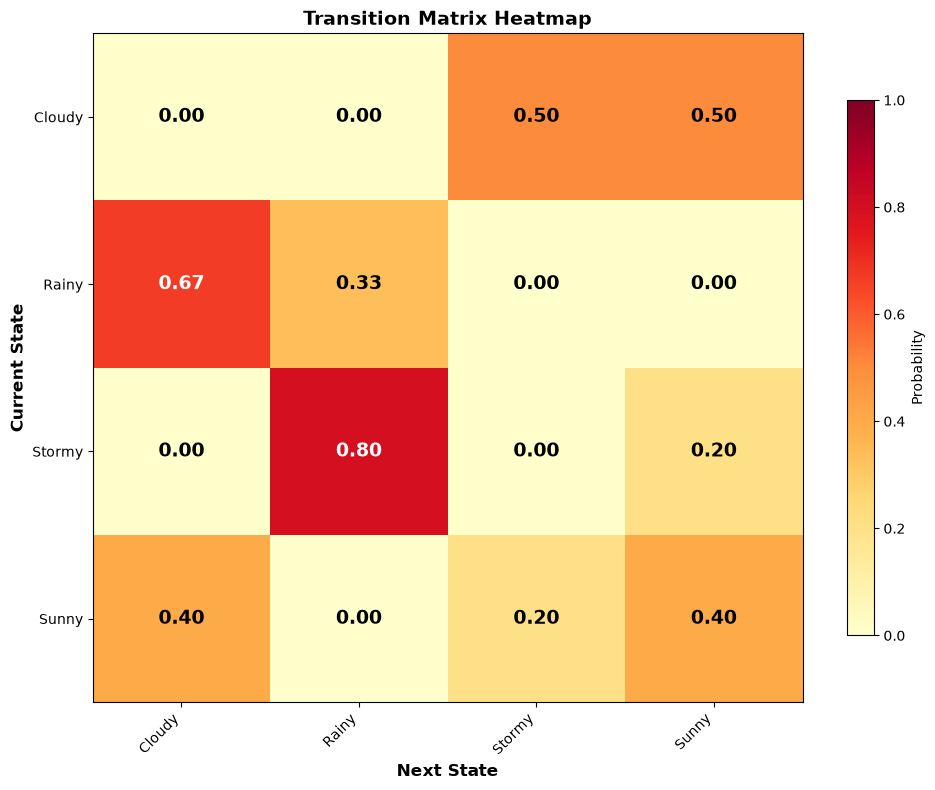

In [15]:
# Your four-state model
four_state_sequence = (['Sunny', 'Sunny', 'Cloudy', 'Stormy', 'Rainy',
                        'Cloudy', 'Sunny', 'Sunny', 'Stormy', 'Rainy',
                        'Rainy', 'Cloudy', 'Sunny', 'Cloudy', 'Stormy'] * 2)[:30]

four_matrix, four_states = create_transition_matrix(four_state_sequence)

print("States:", four_states)
print("\nTransition matrix:")
print(four_matrix)

visualize_transition_matrix(four_matrix, four_states)


### Challenge 3: Convergence Speed
Create a function that determines how many steps it takes for the probabilities to get within 0.01 of the steady state.

In [16]:
def steps_to_convergence(matrix, tolerance=0.01):
    """How many steps until we're close to steady state?"""
    n = matrix.shape[0]

    # A good target: the true steady state, found by iterating for a long time
    target = np.ones(n) / n
    for _ in range(500):
        target = target @ matrix

    # Now start from a uniform distribution and see how fast we get close
    state_prob = np.ones(n) / n
    for step in range(1, 1000):
        state_prob = state_prob @ matrix
        if np.max(np.abs(state_prob - target)) < tolerance:
            return step

    return None  # didn't converge within 1000 steps

steps_needed = steps_to_convergence(matrix, tolerance=0.01)
print(f"Steps to get within 0.01 of the steady state: {steps_needed}")


Steps to get within 0.01 of the steady state: 3


### Challenge 4: Periodic Chains
Create this transition matrix manually:
```
     A    B
A [[0.0, 1.0],
B  [1.0, 0.0]]
```

This alternates: A → B → A → B → ...

Does this have a steady state? What happens when you raise it to high powers?

In [17]:
# Investigate the periodic chain
periodic_matrix = np.array([
    [0.0, 1.0],
    [1.0, 0.0],
])
periodic_states = ['A', 'B']

for power in [1, 2, 3, 4, 10, 11, 20, 21]:
    P_power = np.linalg.matrix_power(periodic_matrix, power)
    print(f"P^{power}:")
    print(P_power)
    print()

print("This chain never settles down: even powers give the identity matrix")
print("(stay put), odd powers give the swap matrix (flip states). There is no")
print("single steady state — the distribution keeps oscillating between A and B")
print("forever, which is what makes this chain periodic rather than convergent.")


P^1:
[[0. 1.]
 [1. 0.]]

P^2:
[[1. 0.]
 [0. 1.]]

P^3:
[[0. 1.]
 [1. 0.]]

P^4:
[[1. 0.]
 [0. 1.]]

P^10:
[[1. 0.]
 [0. 1.]]

P^11:
[[0. 1.]
 [1. 0.]]

P^20:
[[1. 0.]
 [0. 1.]]

P^21:
[[0. 1.]
 [1. 0.]]

This chain never settles down: even powers give the identity matrix
(stay put), odd powers give the swap matrix (flip states). There is no
single steady state — the distribution keeps oscillating between A and B
forever, which is what makes this chain periodic rather than convergent.


### Challenge 5: Absorbing States
Create this transition matrix:
```
       Healthy  Sick  Recovered
Healthy   0.8    0.2    0.0
Sick      0.1    0.4    0.5
Recovered 0.0    0.0    1.0
```

Once you're Recovered, you stay Recovered (absorbing state). 

Starting from Healthy, what's the probability of eventually being Recovered? (Hint: Look at P^100)

In [18]:
# Explore the absorbing state model
health_matrix = np.array([
    [0.8, 0.2, 0.0],
    [0.1, 0.4, 0.5],
    [0.0, 0.0, 1.0],
])
health_states = ['Healthy', 'Sick', 'Recovered']

P100 = np.linalg.matrix_power(health_matrix, 100)
print("P^100:")
print(P100)

healthy_idx = health_states.index('Healthy')
recovered_idx = health_states.index('Recovered')

prob_eventually_recovered = P100[healthy_idx, recovered_idx]
print(f"\nStarting from Healthy, probability of eventually being Recovered: "
      f"{prob_eventually_recovered:.4f}")
print("Since 'Recovered' is absorbing (once there, always there), and every other")
print("state has some path into it, that probability converges to 1.0.")


P^100:
[[4.37776956e-08 1.96776251e-08 9.99999937e-01]
 [9.83881257e-09 4.42244533e-09 9.99999986e-01]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Starting from Healthy, probability of eventually being Recovered: 1.0000
Since 'Recovered' is absorbing (once there, always there), and every other
state has some path into it, that probability converges to 1.0.
